# Football Player Market Value Prediction

This notebook contains the full pipeline for predicting the market value (`market_value_in_eur`) of football players based on transfer records.

## 0. Environment Setup

Creates a `.venv` virtual environment using [uv](https://docs.astral.sh/uv/getting-started/installation/) and installs all required dependencies.

> **uv not installed?** Run the following in your terminal first:
> ```bash
> # Linux / macOS
> curl -LsSf https://astral.sh/uv/install.sh | sh
>
> # Windows (PowerShell)
> powershell -ExecutionPolicy ByPass -c "irm https://astral.sh/uv/install.ps1 | iex"
> ```
> Full installation guide: https://docs.astral.sh/uv/getting-started/installation/

> **Before running the cell below**, bootstrap `ipykernel` into the venv from your terminal — this is required once so that VS Code can use the `.venv` kernel at all:
> ```bash
> uv venv .venv && uv pip install --python .venv/bin/python ipykernel
> ```
> Then select the `.venv` kernel in VS Code and run the cell to install the remaining packages.

In [ ]:
import subprocess, sys

# Verify uv is available
result = subprocess.run(['uv', '--version'], capture_output=True, text=True)
if result.returncode != 0:
    raise EnvironmentError(
        'uv is not installed or not on PATH.\n'
        'Install it from: https://docs.astral.sh/uv/getting-started/installation/'
    )
print(f'uv found: {result.stdout.strip()}')

# Create .venv
subprocess.run(['uv', 'venv', '.venv', '--clear'], check=True)

# Install dependencies into the venv
packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'ipykernel',
]
subprocess.run(
    ['uv', 'pip', 'install', '--python', '.venv/bin/python', *packages],
    check=True,
)
print('\nAll dependencies installed successfully.')

## 1. Imports

Load all required libraries for data manipulation, visualization, and machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
pd.set_option('display.max_columns', None)

## 2. Load Dataset

Read the `transfers.csv` file containing 157,186 football transfer records. The target variable is `market_value_in_eur`.

In [ ]:
df = pd.read_csv('transfers.csv')

print(f'Shape: {df.shape}')
df.head()

## 3. Exploratory Data Analysis (EDA)

Examine the dataset structure, missing values, target distribution, and key relationships.

In [6]:
# Dataset overview
print('Column types:')
print(df.dtypes)
print(f'\nMissing values:')
print(df.isna().sum())
print(f'\nBasic statistics (numeric columns):')
df.describe()

Column types:
player_id                int64
transfer_date              str
transfer_season            str
from_club_id             int64
to_club_id               int64
from_club_name             str
to_club_name               str
transfer_fee           float64
market_value_in_eur    float64
player_name                str
dtype: object

Missing values:
player_id                  0
transfer_date              0
transfer_season            0
from_club_id               0
to_club_id                 0
from_club_name             0
to_club_name               0
transfer_fee           54833
market_value_in_eur    60848
player_name                0
dtype: int64

Basic statistics (numeric columns):


,player_id,from_club_id,to_club_id,transfer_fee,market_value_in_eur
count,1.571860e+05,157186.000000,157186.000000,1.023530e+05,9.633800e+04
mean,5.021871e+05,20156.261461,15612.525040,8.023499e+05,1.882969e+06
std,3.128459e+05,27177.836622,23659.217653,4.441027e+06,4.913449e+06
min,3.333000e+03,1.000000,1.000000,0.000000e+00,1.000000e+04
25%,2.540030e+05,1047.000000,800.000000,0.000000e+00,2.000000e+05
50%,4.488135e+05,8817.000000,4961.000000,0.000000e+00,5.000000e+05
75%,6.982352e+05,28870.000000,18852.000000,0.000000e+00,1.500000e+06
max,1.529719e+06,140641.000000,140573.000000,2.220000e+08,1.800000e+08


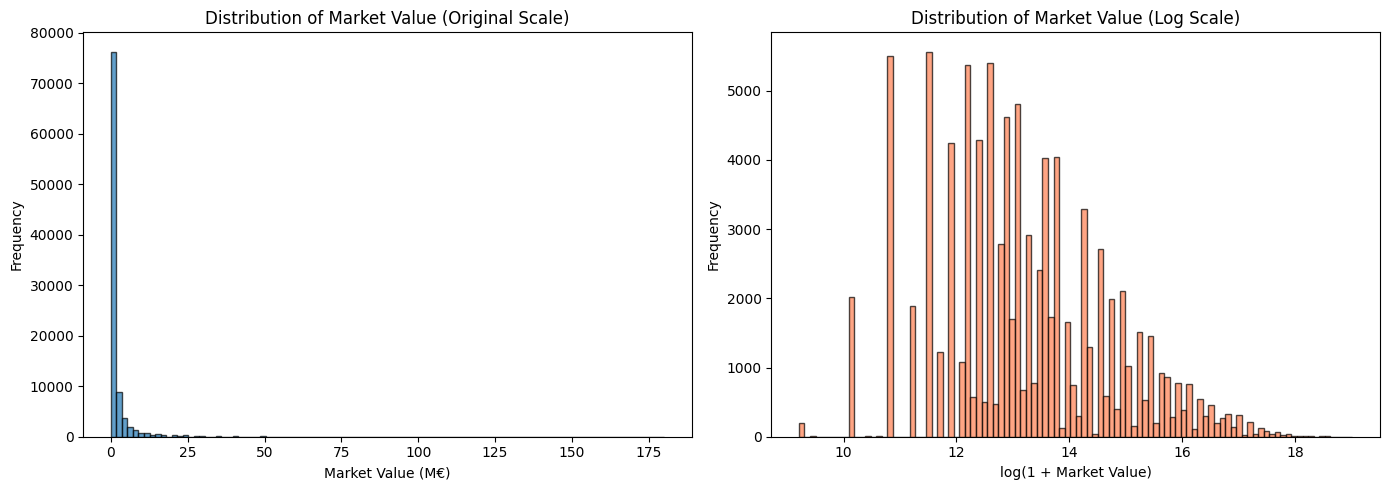

Skewness (original): 8.15
Skewness (log):      0.32


In [7]:
# Target variable distribution
valid_target = df['market_value_in_eur'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original scale
axes[0].hist(valid_target / 1e6, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Market Value (Original Scale)')
axes[0].set_xlabel('Market Value (M\u20ac)')
axes[0].set_ylabel('Frequency')

# Log scale
axes[1].hist(np.log1p(valid_target), bins=100, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Distribution of Market Value (Log Scale)')
axes[1].set_xlabel('log(1 + Market Value)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'Skewness (original): {valid_target.skew():.2f}')
print(f'Skewness (log):      {np.log1p(valid_target).skew():.2f}')

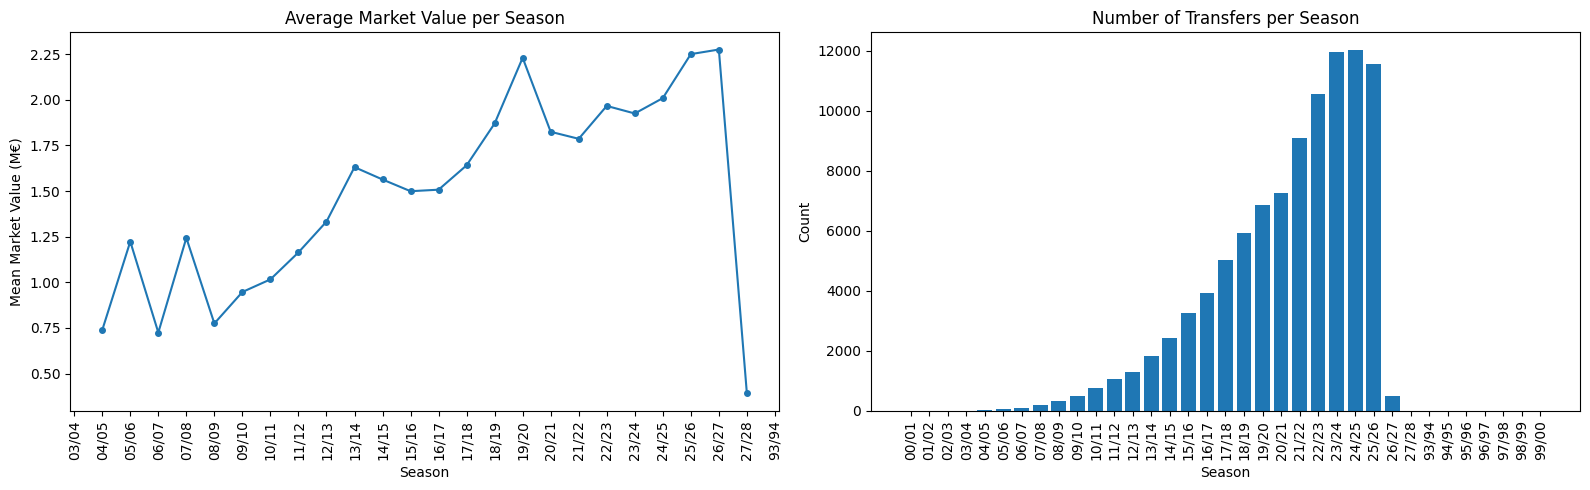

Pearson correlation (transfer_fee vs market_value): 0.6908


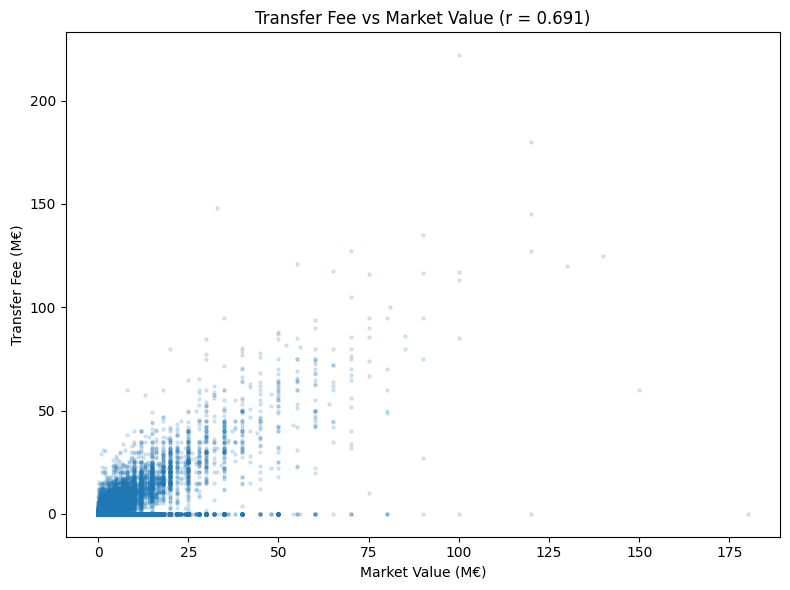

In [8]:
# Season-level summary
season_stats = df.groupby('transfer_season')['market_value_in_eur'].agg(['mean', 'median', 'count'])
season_stats = season_stats.sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(season_stats.index, season_stats['mean'] / 1e6, marker='o', markersize=4)
axes[0].set_title('Average Market Value per Season')
axes[0].set_ylabel('Mean Market Value (M\u20ac)')
axes[0].set_xlabel('Season')
axes[0].tick_params(axis='x', rotation=90)

axes[1].bar(season_stats.index, season_stats['count'])
axes[1].set_title('Number of Transfers per Season')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Season')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

# Correlation: transfer_fee vs market_value
valid_both = df.dropna(subset=['transfer_fee', 'market_value_in_eur'])
corr = valid_both['transfer_fee'].corr(valid_both['market_value_in_eur'])
print(f'Pearson correlation (transfer_fee vs market_value): {corr:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(valid_both['market_value_in_eur'] / 1e6, valid_both['transfer_fee'] / 1e6, alpha=0.15, s=5)
ax.set_xlabel('Market Value (M\u20ac)')
ax.set_ylabel('Transfer Fee (M\u20ac)')
ax.set_title(f'Transfer Fee vs Market Value (r = {corr:.3f})')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Feature Engineering

Steps:
1. Drop rows without a valid target (`market_value_in_eur`).
2. Clean `transfer_fee` (fill NaN with 0) and create `is_free_transfer`.
3. Extract numeric season start year from `transfer_season`.
4. Extract temporal features from `transfer_date` (month, day of year).
5. Target-encode `from_club_id` and `to_club_id` using mean market value (computed on non-test data only to avoid leakage).
6. Apply log-transform to the target variable.

In [9]:
# 4.1 Drop rows without target
df_clean = df.dropna(subset=['market_value_in_eur']).copy()
print(f'Rows with valid target: {len(df_clean):,} (dropped {len(df) - len(df_clean):,})')

# 4.2 Clean transfer_fee and create binary flag
df_clean['transfer_fee_clean'] = df_clean['transfer_fee'].fillna(0)
df_clean['is_free_transfer'] = (df_clean['transfer_fee_clean'] == 0).astype(int)

# 4.3 Season start year (e.g. '24/25' -> 2024)
df_clean['season_start_year'] = df_clean['transfer_season'].apply(
    lambda s: int('20' + s.split('/')[0])
)

# 4.4 Temporal features from transfer_date
df_clean['transfer_date'] = pd.to_datetime(df_clean['transfer_date'])
df_clean['transfer_month'] = df_clean['transfer_date'].dt.month
df_clean['transfer_day_of_year'] = df_clean['transfer_date'].dt.dayofyear

# 4.5 Club target encoding (mean market value per club)
# Compute on NON-test data only to avoid data leakage
train_mask = df_clean['transfer_season'] != '24/25'
train_subset = df_clean[train_mask]

from_club_means = train_subset.groupby('from_club_id')['market_value_in_eur'].mean()
to_club_means = train_subset.groupby('to_club_id')['market_value_in_eur'].mean()
global_mean = train_subset['market_value_in_eur'].mean()

df_clean['from_club_encoded'] = df_clean['from_club_id'].map(from_club_means).fillna(global_mean)
df_clean['to_club_encoded'] = df_clean['to_club_id'].map(to_club_means).fillna(global_mean)

# 4.6 Log-transform target
df_clean['log_market_value'] = np.log1p(df_clean['market_value_in_eur'])

print(f'\nEngineered features:')
print(f'  transfer_fee_clean, is_free_transfer, season_start_year')
print(f'  transfer_month, transfer_day_of_year')
print(f'  from_club_encoded, to_club_encoded')
print(f'  log_market_value (target)')

# Preview
df_clean[['player_name', 'transfer_fee_clean', 'is_free_transfer', 'season_start_year',
          'transfer_month', 'from_club_encoded', 'to_club_encoded',
          'market_value_in_eur', 'log_market_value']].head(10)

Rows with valid target: 96,338 (dropped 60,848)

Engineered features:
  transfer_fee_clean, is_free_transfer, season_start_year
  transfer_month, transfer_day_of_year
  from_club_encoded, to_club_encoded
  log_market_value (target)


,player_name,transfer_fee_clean,is_free_transfer,season_start_year,transfer_month,from_club_encoded,to_club_encoded,market_value_in_eur,log_market_value
0,Luca Belardinelli,0.0,1,2025,6,7.633929e+05,1.997147e+06,700000.0,13.458837
1,Jun-soo Byeon,0.0,1,2027,7,4.362981e+05,5.521127e+05,500000.0,13.122365
2,Jun-su Ahn,0.0,1,2027,7,4.362981e+05,7.594758e+05,350000.0,12.765691
3,Kang-hyun Lee,0.0,1,2027,7,4.362981e+05,2.472619e+05,325000.0,12.691584
4,Luca Pazourek,0.0,1,2026,6,5.162162e+05,6.050000e+05,300000.0,12.611541
5,Emmanuel Essiam,0.0,1,2026,6,5.909091e+05,1.738966e+06,300000.0,12.611541
6,Kendry Páez,0.0,1,2026,6,4.469835e+06,1.526748e+07,9000000.0,16.012735
7,Jan Harustak,0.0,1,2026,6,5.411765e+05,4.473881e+05,200000.0,12.206078
8,Stavros Pnevmonidis,0.0,1,2026,6,6.445833e+05,2.320312e+06,1000000.0,13.815512
9,Min-seo Park,0.0,1,2026,6,4.362981e+05,4.885294e+05,375000.0,12.834684


## 5. Train-Validation-Test Split

Use the **2024/25 season** as the held-out test set (temporal split). The remaining data is split 80/20 into train and validation sets. Features are scaled with `StandardScaler` (fit on train only).

In [10]:
FEATURES = [
    'transfer_fee_clean',
    'is_free_transfer',
    'season_start_year',
    'transfer_month',
    'transfer_day_of_year',
    'from_club_encoded',
    'to_club_encoded',
]

# Temporal split: season 24/25 -> test set
test_mask = df_clean['transfer_season'] == '24/25'
df_test = df_clean[test_mask]
df_trainval = df_clean[~test_mask]

X_trainval = df_trainval[FEATURES]
y_trainval = df_trainval['log_market_value']
X_test = df_test[FEATURES]
y_test = df_test['log_market_value']

# Split train+val into train (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42,
)

# Scale features (fit on train only)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=FEATURES, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURES, index=X_test.index)

# --- Summary of all three groups ---
total = len(X_train) + len(X_val) + len(X_test)
split_summary = pd.DataFrame({
    'Set': ['Train', 'Validation', 'Test (24/25)'],
    'Samples': [len(X_train), len(X_val), len(X_test)],
    'Proportion': [
        f'{len(X_train)/total:.1%}',
        f'{len(X_val)/total:.1%}',
        f'{len(X_test)/total:.1%}',
    ],
    'Target Mean (log)': [
        f'{y_train.mean():.2f}',
        f'{y_val.mean():.2f}',
        f'{y_test.mean():.2f}',
    ],
    'Target Std (log)': [
        f'{y_train.std():.2f}',
        f'{y_val.std():.2f}',
        f'{y_test.std():.2f}',
    ],
})
print('Data Split Summary:')
print('=' * 70)
print(split_summary.to_string(index=False))
print(f'\nFeatures scaled with StandardScaler (fit on train only).')
print(f'Total samples: {total:,}')

Data Split Summary:
         Set  Samples Proportion Target Mean (log) Target Std (log)
       Train    67460      70.0%             13.18             1.52
  Validation    16865      17.5%             13.16             1.53
Test (24/25)    12013      12.5%             13.35             1.44

Features scaled with StandardScaler (fit on train only).
Total samples: 96,338


## 6. Model Training

Train three regression models on the log-transformed target. Use the validation set for hyperparameter tuning, then retrain the best configuration on train + validation before final test evaluation.

### 6.1 Linear Regression (Baseline)

In [11]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

val_r2_lr = lr_model.score(X_val_scaled, y_val)
print(f'Linear Regression \u2014 Val R\u00b2 = {val_r2_lr:.4f}')

# Retrain on train + validation combined
X_tv_scaled = pd.DataFrame(
    scaler.fit_transform(X_trainval),
    columns=FEATURES, index=X_trainval.index,
)
X_test_scaled_final = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURES, index=X_test.index,
)

lr_model = LinearRegression()
lr_model.fit(X_tv_scaled, y_trainval)
print('Retrained on train + validation set.')

Linear Regression — Val R² = 0.5300
Retrained on train + validation set.


### 6.2 Decision Tree Regressor

max_depth    Val R²    
-------------------------
3            0.6090    
5            0.6871    
7            0.7081    
10           0.7120    
15           0.6498    
20           0.5528    
25           0.4913    

Best max_depth = 10 — Val R² = 0.7120


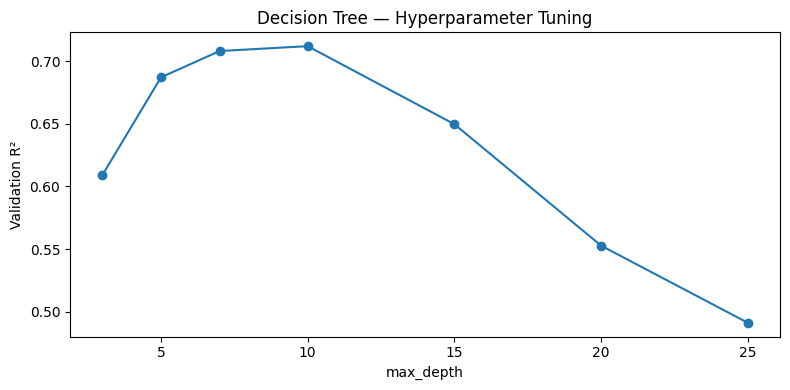

Retrained on train + validation set.


In [12]:
from sklearn.tree import DecisionTreeRegressor

depths = [3, 5, 7, 10, 15, 20, 25]
best_dt_score = -np.inf
best_dt = None
best_depth = None
dt_scores = []

print(f'{"max_depth":<12} {"Val R\u00b2":<10}')
print('-' * 25)

for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    score = dt.score(X_val_scaled, y_val)
    dt_scores.append(score)
    print(f'{d:<12} {score:<10.4f}')
    if score > best_dt_score:
        best_dt_score = score
        best_dt = dt
        best_depth = d

print(f'\nBest max_depth = {best_depth} \u2014 Val R\u00b2 = {best_dt_score:.4f}')

# Plot validation R\u00b2 vs max_depth
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depths, dt_scores, marker='o')
ax.set_xlabel('max_depth')
ax.set_ylabel('Validation R\u00b2')
ax.set_title('Decision Tree \u2014 Hyperparameter Tuning')
plt.tight_layout()
plt.show()

# Retrain on train + validation
best_dt = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
best_dt.fit(X_tv_scaled, y_trainval)
print('Retrained on train + validation set.')

### 6.3 Random Forest Regressor

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf_params = [
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 15},
    {'n_estimators': 200, 'max_depth': 10},
    {'n_estimators': 200, 'max_depth': 15},
    {'n_estimators': 200, 'max_depth': 20},
    {'n_estimators': 300, 'max_depth': 20},
]

best_rf_score = -np.inf
best_rf = None
best_rf_params = None

print(f'{"n_estimators":<15} {"max_depth":<12} {"Val R\u00b2":<10}')
print('-' * 40)

for params in rf_params:
    rf = RandomForestRegressor(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train_scaled, y_train)
    score = rf.score(X_val_scaled, y_val)
    print(f'{params["n_estimators"]:<15} {params["max_depth"]:<12} {score:<10.4f}')
    if score > best_rf_score:
        best_rf_score = score
        best_rf = rf
        best_rf_params = params

print(f'\nBest RF params: {best_rf_params} \u2014 Val R\u00b2 = {best_rf_score:.4f}')

# Retrain best model on train + validation
best_rf = RandomForestRegressor(
    n_estimators=best_rf_params['n_estimators'],
    max_depth=best_rf_params['max_depth'],
    random_state=42,
    n_jobs=-1,
)
best_rf.fit(X_tv_scaled, y_trainval)
print('Retrained on train + validation set.')

n_estimators    max_depth    Val R²    
----------------------------------------
100             10           0.7273    
100             15           0.7291    
200             10           0.7274    
200             15           0.7299    
200             20           0.7240    
300             20           0.7243    

Best RF params: {'n_estimators': 200, 'max_depth': 15} — Val R² = 0.7299
Retrained on train + validation set.


## 7. Model Evaluation & Comparison

Compare all three models on the held-out test set (season 2024/25) using:
- **RMSE (log scale)** — primary metric on the transformed target.
- **R\u00b2** — proportion of variance explained.
- **MAE (\u20ac)** — interpretable error in original euro scale.

Model Comparison on Test Set (Season 2024/25):
            Model  RMSE (log)     R²    MAE (€)
Linear Regression      1.0157 0.5022 1674402.69
    Decision Tree      0.8951 0.6134 1061952.07
    Random Forest      0.8719 0.6332 1017456.72


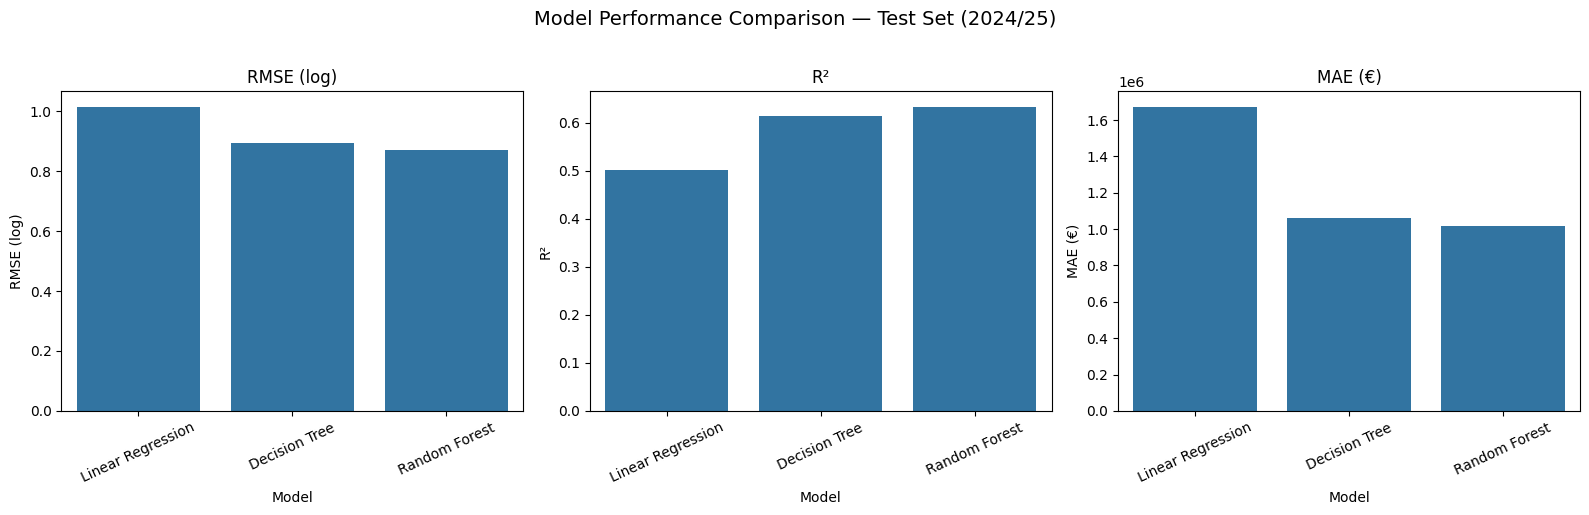

In [14]:
models = {
    'Linear Regression': lr_model,
    'Decision Tree': best_dt,
    'Random Forest': best_rf,
}

results = []
for name, model in models.items():
    y_pred_log = model.predict(X_test_scaled_final)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    r2 = r2_score(y_test, y_pred_log)
    mae = mean_absolute_error(y_true, y_pred)

    results.append({
        'Model': name,
        'RMSE (log)': round(rmse_log, 4),
        'R\u00b2': round(r2, 4),
        'MAE (\u20ac)': round(mae, 2),
    })

results_df = pd.DataFrame(results)
print('Model Comparison on Test Set (Season 2024/25):')
print('=' * 65)
print(results_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['RMSE (log)', 'R\u00b2', 'MAE (\u20ac)']):
    sns.barplot(data=results_df, x='Model', y=metric, ax=ax)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Model Performance Comparison \u2014 Test Set (2024/25)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

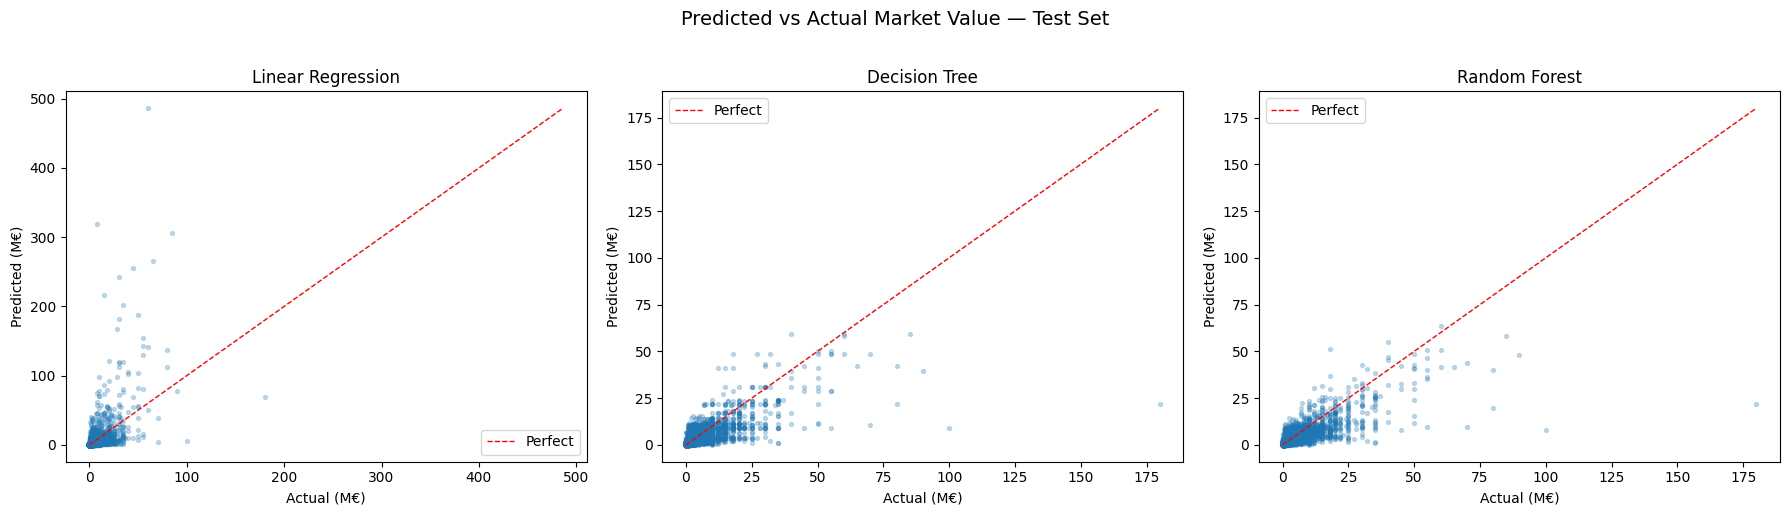

In [15]:
# Predicted vs Actual scatter plot for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred_log = model.predict(X_test_scaled_final)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    ax.scatter(y_true / 1e6, y_pred / 1e6, alpha=0.25, s=8)
    max_val = max(y_true.max(), y_pred.max()) / 1e6
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect')
    ax.set_xlabel('Actual (M\u20ac)')
    ax.set_ylabel('Predicted (M\u20ac)')
    ax.set_title(name)
    ax.legend()

plt.suptitle('Predicted vs Actual Market Value \u2014 Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

Identify and rank the variables with the greatest influence on the predicted market value using the Random Forest model's built-in feature importances.

Feature Importance Ranking (Random Forest):
  from_club_encoded.................. 0.5821
  to_club_encoded.................... 0.2916
  transfer_fee_clean................. 0.0637
  season_start_year.................. 0.0295
  transfer_day_of_year............... 0.0265
  transfer_month..................... 0.0058
  is_free_transfer................... 0.0008


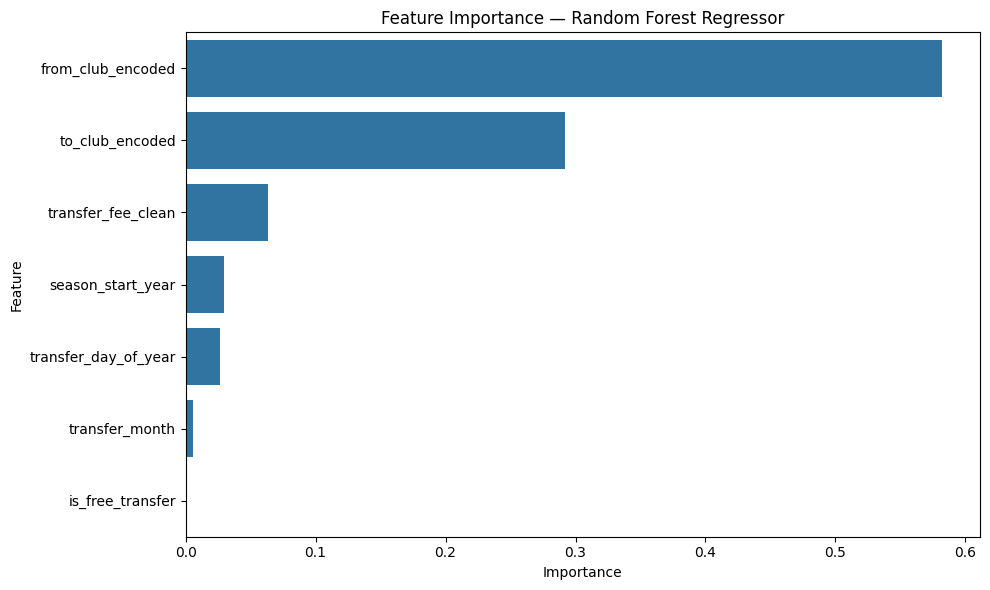

In [16]:
# Feature importance from the Random Forest model
importances = best_rf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': importances,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Feature Importance Ranking (Random Forest):')
print('=' * 50)
for _, row in importance_df.iterrows():
    print(f'  {row["Feature"]:.<35} {row["Importance"]:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', ax=ax)
ax.set_title('Feature Importance \u2014 Random Forest Regressor')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 9. Model Success Rate

For each model, compute the percentage of test predictions that fall within a given tolerance of the actual market value (e.g., within 10%, 25%, 50% of the true value).

Prediction Success Rate on Test Set (Season 2024/25):
            Model Within 10% Within 25% Within 50%
Linear Regression       8.8%      22.3%      44.7%
    Decision Tree      10.4%      27.1%      53.5%
    Random Forest      11.1%      27.7%      55.1%


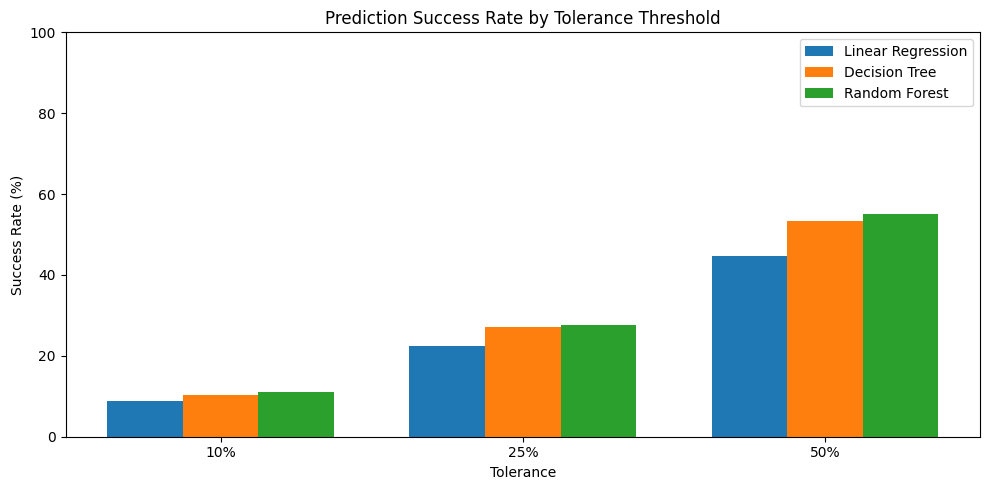

In [17]:
tolerances = [0.10, 0.25, 0.50]

success_rows = []
for name, model in models.items():
    y_pred_log = model.predict(X_test_scaled_final)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test).values

    # Relative error per prediction
    rel_error = np.abs(y_pred - y_true) / y_true

    row = {'Model': name}
    for tol in tolerances:
        pct = (rel_error <= tol).mean() * 100
        row[f'Within {tol:.0%}'] = f'{pct:.1f}%'
    success_rows.append(row)

success_df = pd.DataFrame(success_rows)
print('Prediction Success Rate on Test Set (Season 2024/25):')
print('=' * 60)
print(success_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(tolerances))
width = 0.25

for i, (name, model) in enumerate(models.items()):
    y_pred_log = model.predict(X_test_scaled_final)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test).values
    rel_error = np.abs(y_pred - y_true) / y_true
    pcts = [(rel_error <= tol).mean() * 100 for tol in tolerances]
    ax.bar(x + i * width, pcts, width, label=name)

ax.set_xlabel('Tolerance')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Prediction Success Rate by Tolerance Threshold')
ax.set_xticks(x + width)
ax.set_xticklabels([f'{t:.0%}' for t in tolerances])
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()